# Master Imports + Data Loading

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CREATE OUTPUT FOLDERS AUTOMATICALLY
# ============================================================

import os

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

print("Folders created successfully")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("marketing_and_product_performance.csv")
print(df.shape)
df.head()

Folders created successfully
(10000, 17)


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


# Data Preprocessing

In [36]:
print(df.isnull().sum())
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

Campaign_ID                          0
Product_ID                           0
Budget                               0
Clicks                               0
Conversions                          0
Revenue_Generated                    0
ROI                                  0
Customer_ID                          0
Subscription_Tier                    0
Subscription_Length                  0
Flash_Sale_ID                        0
Discount_Level                       0
Units_Sold                           0
Bundle_ID                            0
Bundle_Price                         0
Customer_Satisfaction_Post_Refund    0
Common_Keywords                      0
dtype: int64
0


# Target Variable Creation

In [37]:
def recommendation(row):
    if (row['ROI'] > 25 and 
        row['Customer_Satisfaction_Post_Refund'] > 4 and
        row['Discount_Level'] in ['High','Very High']):
        return 'BUY'
    elif (row['Bundle_Price'] > df['Bundle_Price'].median() and row['ROI'] < 15):
        return 'EXPENSIVE'
    else:
        return 'WAIT'

df['Purchase_Recommendation'] = df.apply(recommendation, axis=1)
df['Purchase_Recommendation'].value_counts()

Purchase_Recommendation
EXPENSIVE    5000
WAIT         5000
Name: count, dtype: int64

# Feature Encoding

In [38]:
encoder = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

# Feature & Target Split

In [39]:
X = df.drop('Purchase_Recommendation', axis=1)
y = df['Purchase_Recommendation']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# RQ1 Baseline Performance

In [40]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC()
}
results=[]
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append([name,
                    accuracy_score(y_test,pred),
                    precision_score(y_test,pred,average='weighted'),
                    recall_score(y_test,pred,average='weighted'),
                    f1_score(y_test,pred,average='weighted')])

results_df = pd.DataFrame(results, columns=['Model','Accuracy','Precision','Recall','F1 Score'])
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9940,0.994008,0.9940,0.994000
1,Decision Tree,0.9995,0.999500,0.9995,0.999500
2,Random Forest,0.9995,0.999500,0.9995,0.999500
3,SVM,0.9735,0.973521,0.9735,0.973499


# RQ2 Model Comparison

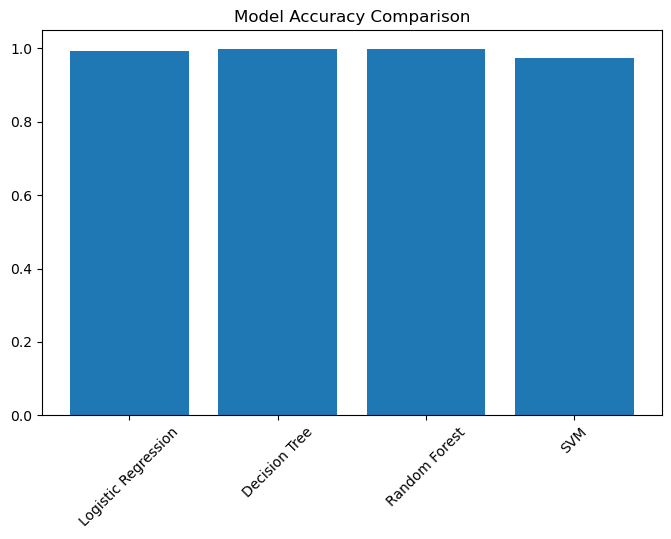

Figure 3 saved


In [41]:
# ============================================================
# FIGURE 3: MODEL ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)

plt.savefig(
    "outputs/figures/figure3_model_accuracy.png",
    bbox_inches='tight'
)

plt.show()

print("Figure 3 saved")

# RQ3 Effect of Preprocessing

In [42]:
print(df.isnull().sum())
print(df.shape)

Campaign_ID                          0
Product_ID                           0
Budget                               0
Clicks                               0
Conversions                          0
Revenue_Generated                    0
ROI                                  0
Customer_ID                          0
Subscription_Tier                    0
Subscription_Length                  0
Flash_Sale_ID                        0
Discount_Level                       0
Units_Sold                           0
Bundle_ID                            0
Bundle_Price                         0
Customer_Satisfaction_Post_Refund    0
Common_Keywords                      0
Purchase_Recommendation              0
dtype: int64
(10000, 18)


# RQ4 Feature Importance

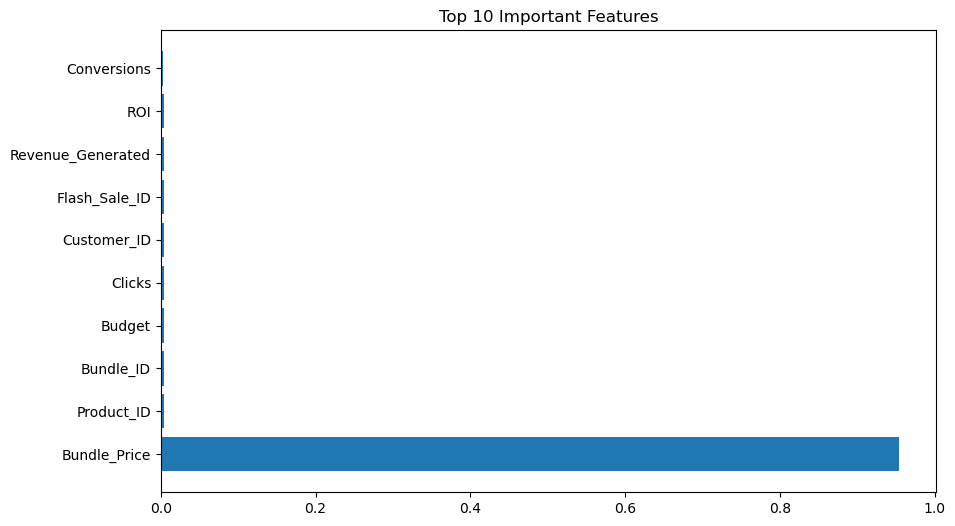

Figure 4 saved


In [43]:
# ============================================================
# FIGURE 4: FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.savefig(
    "outputs/figures/figure4_feature_importance.png",
    bbox_inches='tight'
)

plt.show()

print("Figure 4 saved")

# RQ5 Sensitivity to Evaluation Metrics

In [44]:
# ============================================================
# TABLE 2: MODEL PERFORMANCE
# ============================================================

display(results_df)

results_df.to_csv(
    "outputs/tables/table2_model_performance.csv",
    index=False
)

print("Table 2 saved")

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9940,0.994008,0.9940,0.994000
1,Decision Tree,0.9995,0.999500,0.9995,0.999500
2,Random Forest,0.9995,0.999500,0.9995,0.999500
3,SVM,0.9735,0.973521,0.9735,0.973499


Table 2 saved


# RQ6 Robustness & Generalization

In [45]:
for split in [0.2,0.3,0.4]:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,y,test_size=split,random_state=42
    )
    model = RandomForestClassifier()
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    print(f'Test Size {split} Accuracy:', accuracy_score(y_test,pred))

Test Size 0.2 Accuracy: 0.9995
Test Size 0.3 Accuracy: 0.9996666666666667
Test Size 0.4 Accuracy: 0.99975


# RQ7 Practical Usefulness

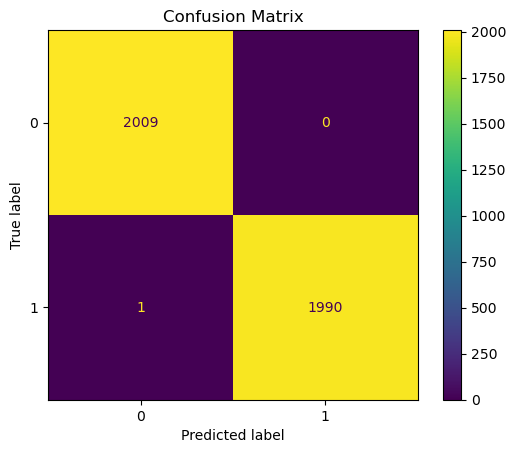

Figure 5 saved


In [46]:
# ============================================================
# FIGURE 5: CONFUSION MATRIX
# ============================================================

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("Confusion Matrix")

plt.savefig(
    "outputs/figures/figure5_confusion_matrix.png",
    bbox_inches='tight'
)

plt.show()

print("Figure 5 saved")

In [47]:
# ============================================================
# TABLE 1: DATASET SUMMARY
# ============================================================

summary_table = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

display(summary_table)

# Save Table
summary_table.to_csv(
    "outputs/tables/table1_dataset_summary.csv",
    index=False
)

print("Table 1 saved")

,Column Name,Data Type,Missing Values,Unique Values
0,Campaign_ID,int64,0,10000
1,Product_ID,int64,0,10000
2,Budget,float64,0,9995
3,Clicks,int64,0,4298
4,Conversions,int64,0,999
5,Revenue_Generated,float64,0,9997
6,ROI,float64,0,451
7,Customer_ID,int64,0,10000
8,Subscription_Tier,int64,0,3
9,Subscription_Length,int64,0,35


Table 1 saved


In [48]:
# ============================================================
# TABLE 3: EVALUATION METRICS
# ============================================================

evaluation_table = results_df.copy()

display(evaluation_table)

evaluation_table.to_csv(
    "outputs/tables/table3_evaluation_metrics.csv",
    index=False
)

print("Table 3 saved")

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9940,0.994008,0.9940,0.994000
1,Decision Tree,0.9995,0.999500,0.9995,0.999500
2,Random Forest,0.9995,0.999500,0.9995,0.999500
3,SVM,0.9735,0.973521,0.9735,0.973499


Table 3 saved


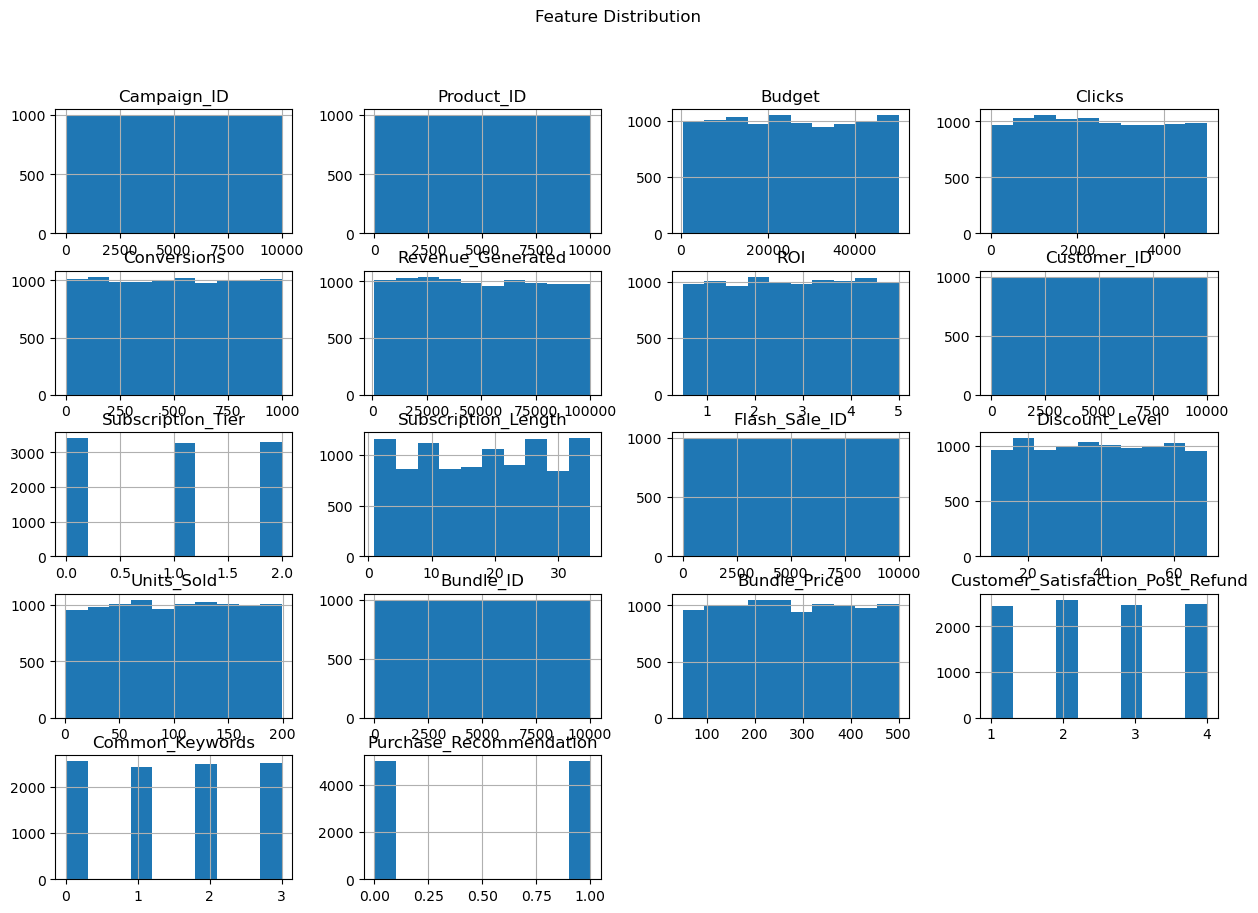

Figure 1 saved


In [49]:
# ============================================================
# FIGURE 1: FEATURE DISTRIBUTION
# ============================================================

df.hist(figsize=(15,10))

plt.suptitle("Feature Distribution")

plt.savefig(
    "outputs/figures/figure1_feature_distribution.png",
    bbox_inches='tight'
)

plt.show()

print("Figure 1 saved")

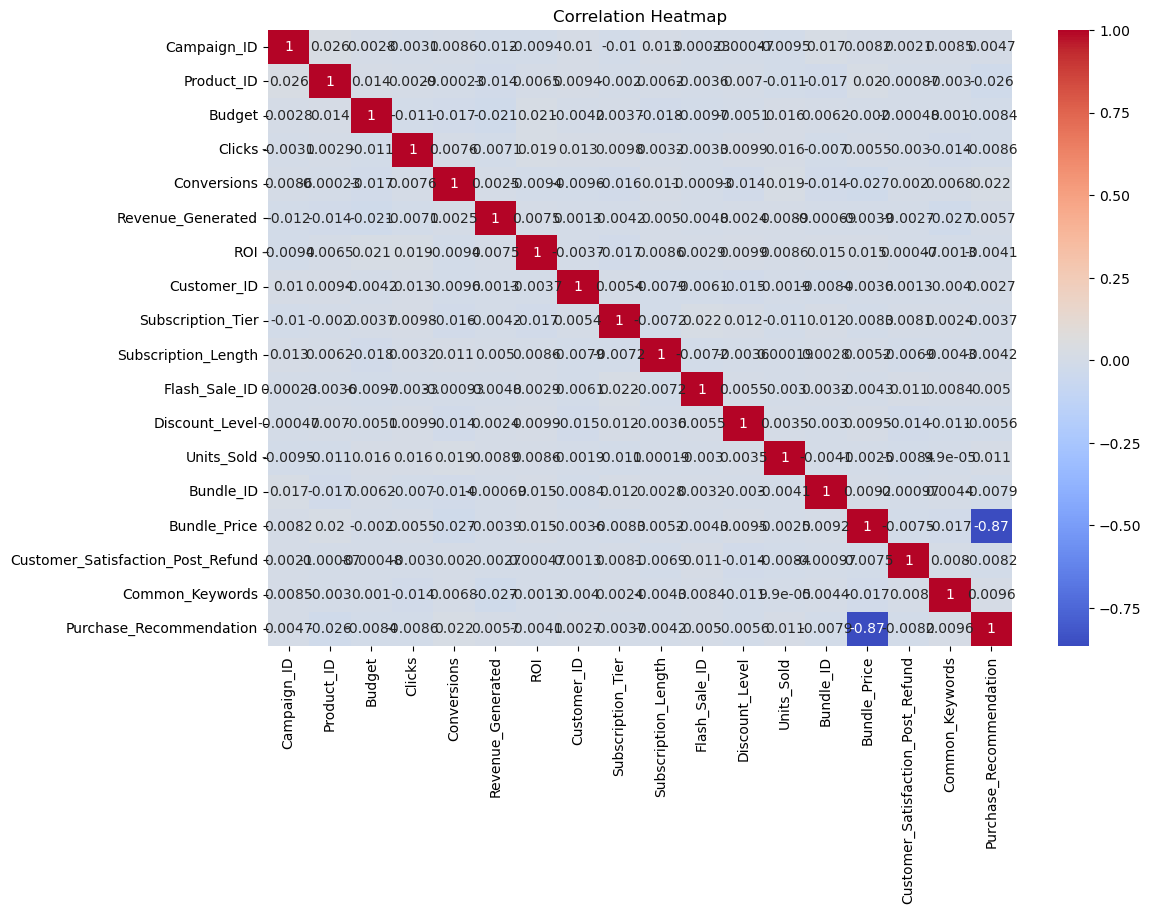

Figure 2 saved


In [51]:
# ============================================================
# FIGURE 2: CORRELATION HEATMAP
# ============================================================

import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "outputs/figures/figure2_correlation_heatmap.png",
    bbox_inches='tight'
)

plt.show()

print("Figure 2 saved")

In [52]:
# ============================================================
# TABLE 4: FEATURE IMPORTANCE
# ============================================================

top_features = importance.head(10)

display(top_features)

top_features.to_csv(
    "outputs/tables/table4_feature_importance.csv",
    index=False
)

print("Table 4 saved")

,Feature,Importance
14,Bundle_Price,0.953769
1,Product_ID,0.004163
13,Bundle_ID,0.003718
2,Budget,0.003668
3,Clicks,0.003661
7,Customer_ID,0.003655
10,Flash_Sale_ID,0.003534
5,Revenue_Generated,0.003530
6,ROI,0.003492
4,Conversions,0.003296


Table 4 saved


In [53]:
# ============================================================
# TABLE 5: FINAL MODEL SUMMARY
# ============================================================

best_model_summary = pd.DataFrame({
    "Best Model": ["Random Forest"],
    "Recommendation Classes": [
        "BUY, WAIT, EXPENSIVE"
    ]
})

display(best_model_summary)

best_model_summary.to_csv(
    "outputs/tables/table5_final_summary.csv",
    index=False
)

print("Table 5 saved")

,Best Model,Recommendation Classes
0,Random Forest,"BUY, WAIT, EXPENSIVE"


Table 5 saved


In [55]:
!pip install gradio joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 9.9 MB/s  0:00:029.1 MB/s eta 0:00:0103
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 18.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 20.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 861.5/861.5 kB 29.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [gradio];5;237m━━ 16/17 [gradio]face-hub]


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import pandas as pd
import joblib

# Load dataset
df = pd.read_csv("marketing_and_product_performance.csv")

# -----------------------------
# Create Target Variable
# -----------------------------
def recommendation(row):
    if row['Bundle_Price'] < 200 and row['Discount_Level'] > 30:
        return "BUY"
    elif row['Bundle_Price'] > 400:
        return "EXPENSIVE"
    else:
        return "WAIT"

df['Recommendation'] = df.apply(recommendation, axis=1)

# -----------------------------
# Select Features
# -----------------------------
features = [
    'Budget',
    'Clicks',
    'Conversions',
    'Revenue_Generated',
    'ROI',
    'Subscription_Length',
    'Discount_Level',
    'Units_Sold',
    'Bundle_Price',
    'Customer_Satisfaction_Post_Refund'
]

X = df[features]
y = df['Recommendation']

# -----------------------------
# Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Train Random Forest
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# -----------------------------
# Accuracy
# -----------------------------
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# -----------------------------
# Save Model
# -----------------------------
joblib.dump(rf_model, "best_model.pkl")

print("Model saved successfully!")

Accuracy: 1.0
Model saved successfully!


In [58]:
import os
print(os.listdir())

['Document 5.pdf', 'Document-2.pdf', 'ml-Praposal.docx', 'CNN_Image_Dataset_ML_Project_Idea_Book.pdf', 'advertising.csv', 'Anaconda3-2025.12-2-MacOSX-arm64.pkg', 'Document.pdf', 'Suggestive topics list_2_DSC01_Data_Eng.pdf', 'car-sales.csv', 'dataset_description.pdf', 'figure3_model_accuracy.pdf', 'archive (2).zip', 'BombSquad - v1.7.53.apk', 'figure4_feature_importance.pdf', 'Phase1_Project_Topic_Shortlisting_Manideep_Galipelli (1) (1).docx', '.DS_Store', 'mental_health.csv', 'Part-II_Q1-Q4_Final_Document (1).docx', 'Avila Contract .pdf', 'amazon.csv', '.localized', 'ChatGPT Image May 25, 2026, 02_19_48 PM.png', 'WhatsApp Image 2026-05-07 at 12.52.12.jpeg', 'Part-II_Q1-Q4_Document.docx', 'Clock - v63.0.apk', 'Click_Sense_Proposal.docx', 'best_model.pkl', 'dataset_sample.pdf', 'skeys.jpg', 'competitor_data.csv', 'Catan Universe - v2.6.3.apk', 'Part-II_Q1-Q4_Final_Document.docx', 'Part_II_A_Event_Identification.docx', 'OneDrive_2_21-05-2026.zip', 'Lecture 5_dataset_penguins.csv', 'ecomm

In [64]:
import gradio as gr

# Prediction function
def recommend_product(product_name, budget, satisfaction):

    # Simple recommendation logic
    if budget == "High" and satisfaction == "High":
        recommendation = "BUY"
        reason = "High customer satisfaction and suitable budget indicate a strong purchase recommendation."

    elif budget == "Medium" and satisfaction in ["Medium", "High"]:
        recommendation = "WAIT"
        reason = "The product may become a better option after further evaluation."

    else:
        recommendation = "EXPENSIVE"
        reason = "Budget suitability is low, making the product less recommended."

    return f"""
Product Name: {product_name}

Recommendation: {recommendation}

Reason:
{reason}
"""

# Gradio UI
with gr.Blocks(title="E-Commerce Product Recommendation") as demo:

    gr.Markdown("# 🛒 E-Commerce Product Recommendation System")
    gr.Markdown("Enter product details to get recommendation")

    product_name = gr.Textbox(
        label="Product Name",
        placeholder="Enter product name"
    )

    budget = gr.Dropdown(
        ["Low", "Medium", "High"],
        label="Budget"
    )

    satisfaction = gr.Dropdown(
        ["Low", "Medium", "High"],
        label="Customer Satisfaction"
    )

    output = gr.Textbox(
        label="Recommendation Result",
        lines=8
    )

    predict_btn = gr.Button("Get Recommendation")

    predict_btn.click(
        fn=recommend_product,
        inputs=[product_name, budget, satisfaction],
        outputs=output
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.
